In [ ]:
import numpy as np
import os 
import matplotlib.pyplot as plt
import matplotlib
import functions.zone2line as z2l

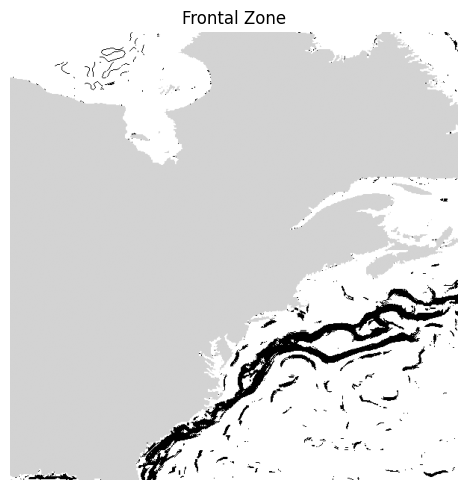

In [4]:
region = '03'
path = os.path.join('./data/regions', region)

probability = np.load(os.path.join(path, 'probability.npy'))

frontal_zone = probability.copy()
frontal_zone[frontal_zone < 0.5] = 0
frontal_zone[frontal_zone >= 0.5] = 1

plt.figure(figsize=(5, 5))
current_cmap = matplotlib.colormaps.get_cmap('binary')
current_cmap.set_bad(color='lightgray')
plt.imshow(np.flipud(frontal_zone), cmap=current_cmap)
plt.title('Frontal Zone')
plt.axis('off')
plt.tight_layout()

In [5]:
gradient_direction = np.load(os.path.join(path, 'gradient_direction.npy'))

frontal_line, _, fronts = z2l.zone2line(frontal_zone, gradient_direction, 'SST')

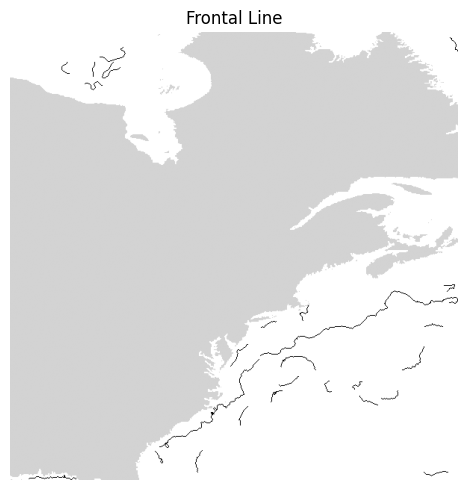

In [6]:
plt.figure(figsize=(5, 5))
plt.imshow(np.flipud(frontal_line), cmap=current_cmap)
plt.title('Frontal Line')
plt.axis('off')
plt.tight_layout()

In [7]:
import geojson

In [10]:
lon = np.load(os.path.join(path, 'lon_extracted.npy'))
lat = np.load(os.path.join(path, 'lat_extracted.npy'))

probability_list = []
fronts_lonlat = []

for front in fronts:
    probability_temp = 0
    front_lonlat = []
    for point in front:
        x, y = point
        probability_temp += probability[x, y]
        lon_val = lon[y]
        lat_val = lat[x]
        front_lonlat.append((lon_val, lat_val))
    fronts_lonlat.append(front_lonlat)
    probability_list.append(probability_temp/len(front))

features = []

for front_idx, coords in enumerate(fronts_lonlat):
    coords = [(float(lon), float(lat)) for lon, lat in coords]
    line = geojson.LineString(coords)
    feature = geojson.Feature(geometry=line, properties={"probability": float(probability_list[front_idx]), "length (km)": int(len(coords) * 5), "id": front_idx + 1})
    features.append(feature)

feature_collection = geojson.FeatureCollection(features)


with open("./data/20240101_region_03_frontlines.geojson", 'w') as f:
    geojson.dump(feature_collection, f, indent=2)